# Water Potability Prediction — Final Project
## Machine Learning Fundamentals — University of Isfahan

**Course:** Machine Learning  
**Instructor:** Dr. Maedeh Jamali  

---

### 👥 Group Members / Developers
* [**Amin Mahvash Mohammadi**](https://www.kaggle.com/aminmahvash)
* [**Sadra Barani**](https://www.kaggle.com/sadrabarani)
---
### Project Overview

The goal of this project is to go through a complete, standard machine learning pipeline to predict the **potability of water** (whether it is safe to drink) based on its chemical and physical properties. The project consists of three main phases:

1. **Phase 1 — Preprocessing & Exploratory Data Analysis (EDA)**  
   Getting familiar with the data, statistical and visual analysis, handling missing values, and feature scaling.

2. **Phase 2 — Supervised Learning (Classification Models)**  
   Implementing and training a variety of classification algorithms: Logistic Regression, KNN, SVM, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, MLP Classifier, and bonus models (XGBoost, LightGBM, Extra Trees, Gaussian Naive Bayes).

3. **Phase 3 — Comprehensive Evaluation & Comparison**  
   Evaluating all models using Accuracy, Precision, Recall, F1-Score, plotting a Confusion Matrix for each model, and a final comprehensive comparison.
---

# Phase 1 — Preprocessing & Exploratory Data Analysis (EDA)

## 1.1 Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


**What we did:** We imported `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for visualization, and only the preprocessing utilities `train_test_split` and `StandardScaler` from scikit-learn — these split/rescale data and do not implement any classification algorithm.

## 1.2 Load the Dataset

In [ ]:
df = pd.read_csv("/kaggle/input/datasets/aminmahvash/water-potability/water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


**What we did:** Loaded the dataset and inspected the first rows.

## 1.3 Dataset Overview

In [ ]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.dtypes)
df.info()

Dataset shape: 3276 rows, 10 columns
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), 

**What we did:** Checked shape, types, and non-null counts per column.

## 1.4 Target Variable Distribution

Class counts:
 Potability
0    1998
1    1278
Name: count, dtype: int64

Class percentages:
 Potability
0    60.99
1    39.01
Name: proportion, dtype: float64


/tmp/ipykernel_58/1278683716.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Potability', data=df, palette=['#e74c3c', '#2ecc71'])


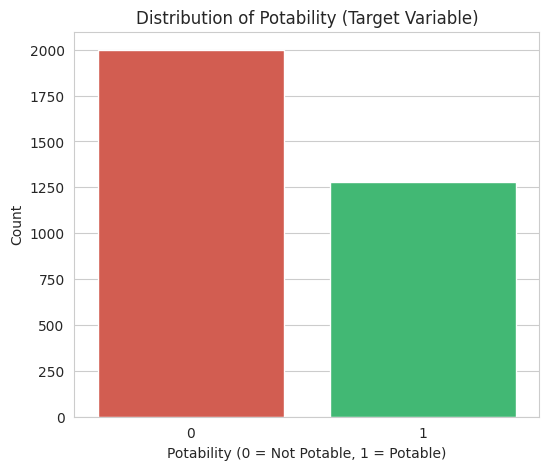

In [ ]:
target_counts = df['Potability'].value_counts()
target_pct = df['Potability'].value_counts(normalize=True) * 100

print("Class counts:\n", target_counts)
print("\nClass percentages:\n", target_pct.round(2))

plt.figure(figsize=(6, 5))
sns.countplot(x='Potability', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title("Distribution of Potability (Target Variable)")
plt.xlabel("Potability (0 = Not Potable, 1 = Potable)")
plt.ylabel("Count")
plt.show()

**What we did:** Confirmed a moderate class imbalance (~61% not potable / 39% potable), which is why we use stratified splitting and F1-score (rather than accuracy) to tune models later.

## 1.5 Checking Missing Values

                 Missing Count  Missing %
Sulfate                    781      23.84
ph                         491      14.99
Trihalomethanes            162       4.95


/tmp/ipykernel_58/1079779505.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Missing %'], palette='rocket')


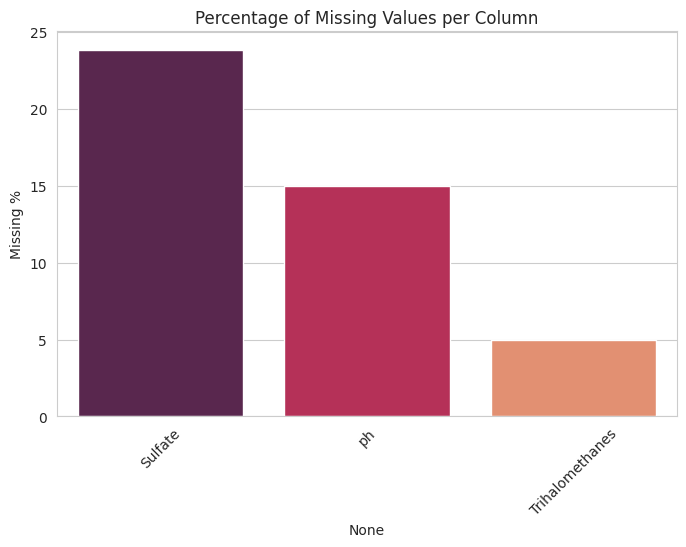

In [ ]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_df.index, y=missing_df['Missing %'], palette='rocket')
plt.title("Percentage of Missing Values per Column")
plt.xticks(rotation=45)
plt.show()

**What we did:** Identified missing values in `ph`, `Sulfate`, and `Trihalomethanes`.

## 1.6 Statistical Summary

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


**What we did:** Reviewed scale/spread of each feature, confirming the need for scaling.

## 1.7 Feature Distributions — Histograms

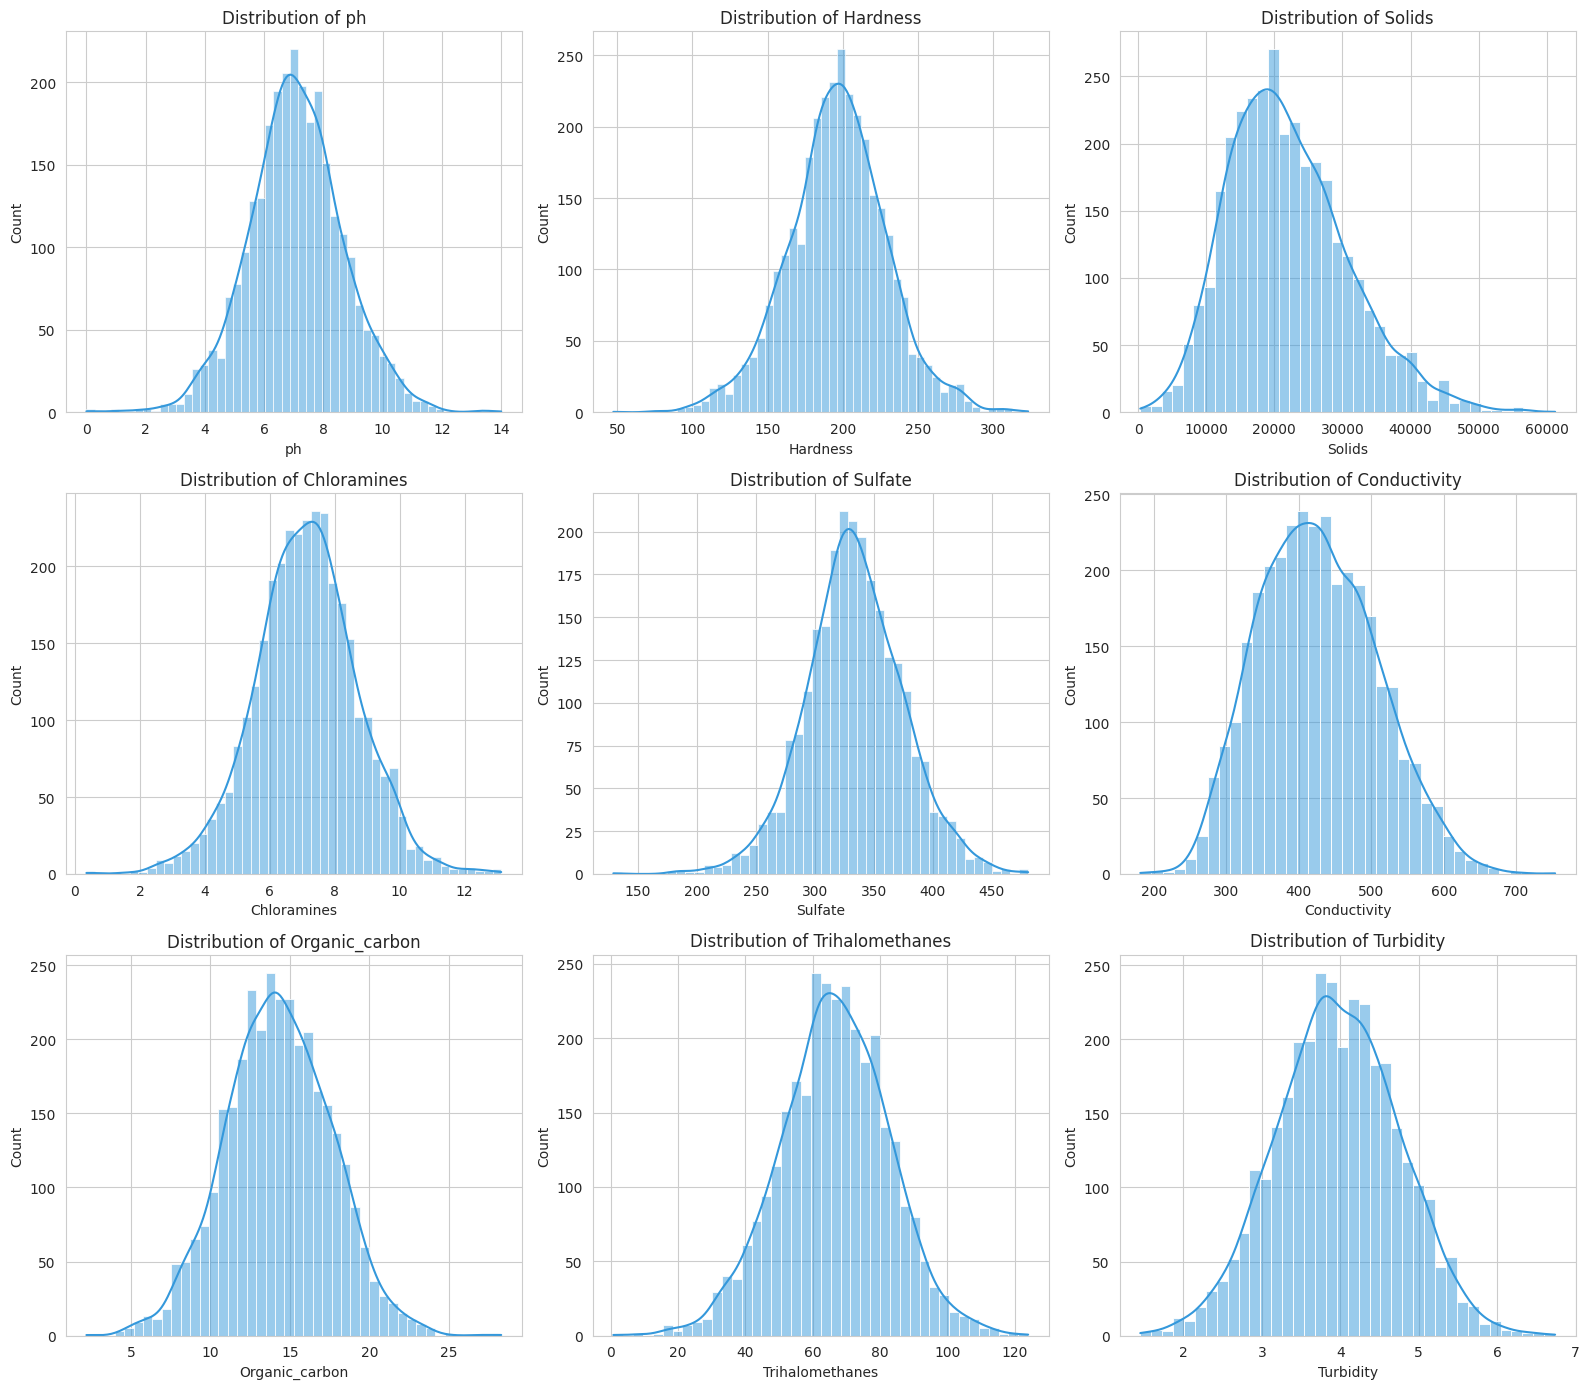

In [ ]:
features = df.columns.drop('Potability')
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='#3498db')
    axes[i].set_title(f'Distribution of {col}')
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**What we did:** Inspected distribution shapes — most features are close to normal, supporting median/mean imputation.

## 1.8 Outlier Detection — Boxplots

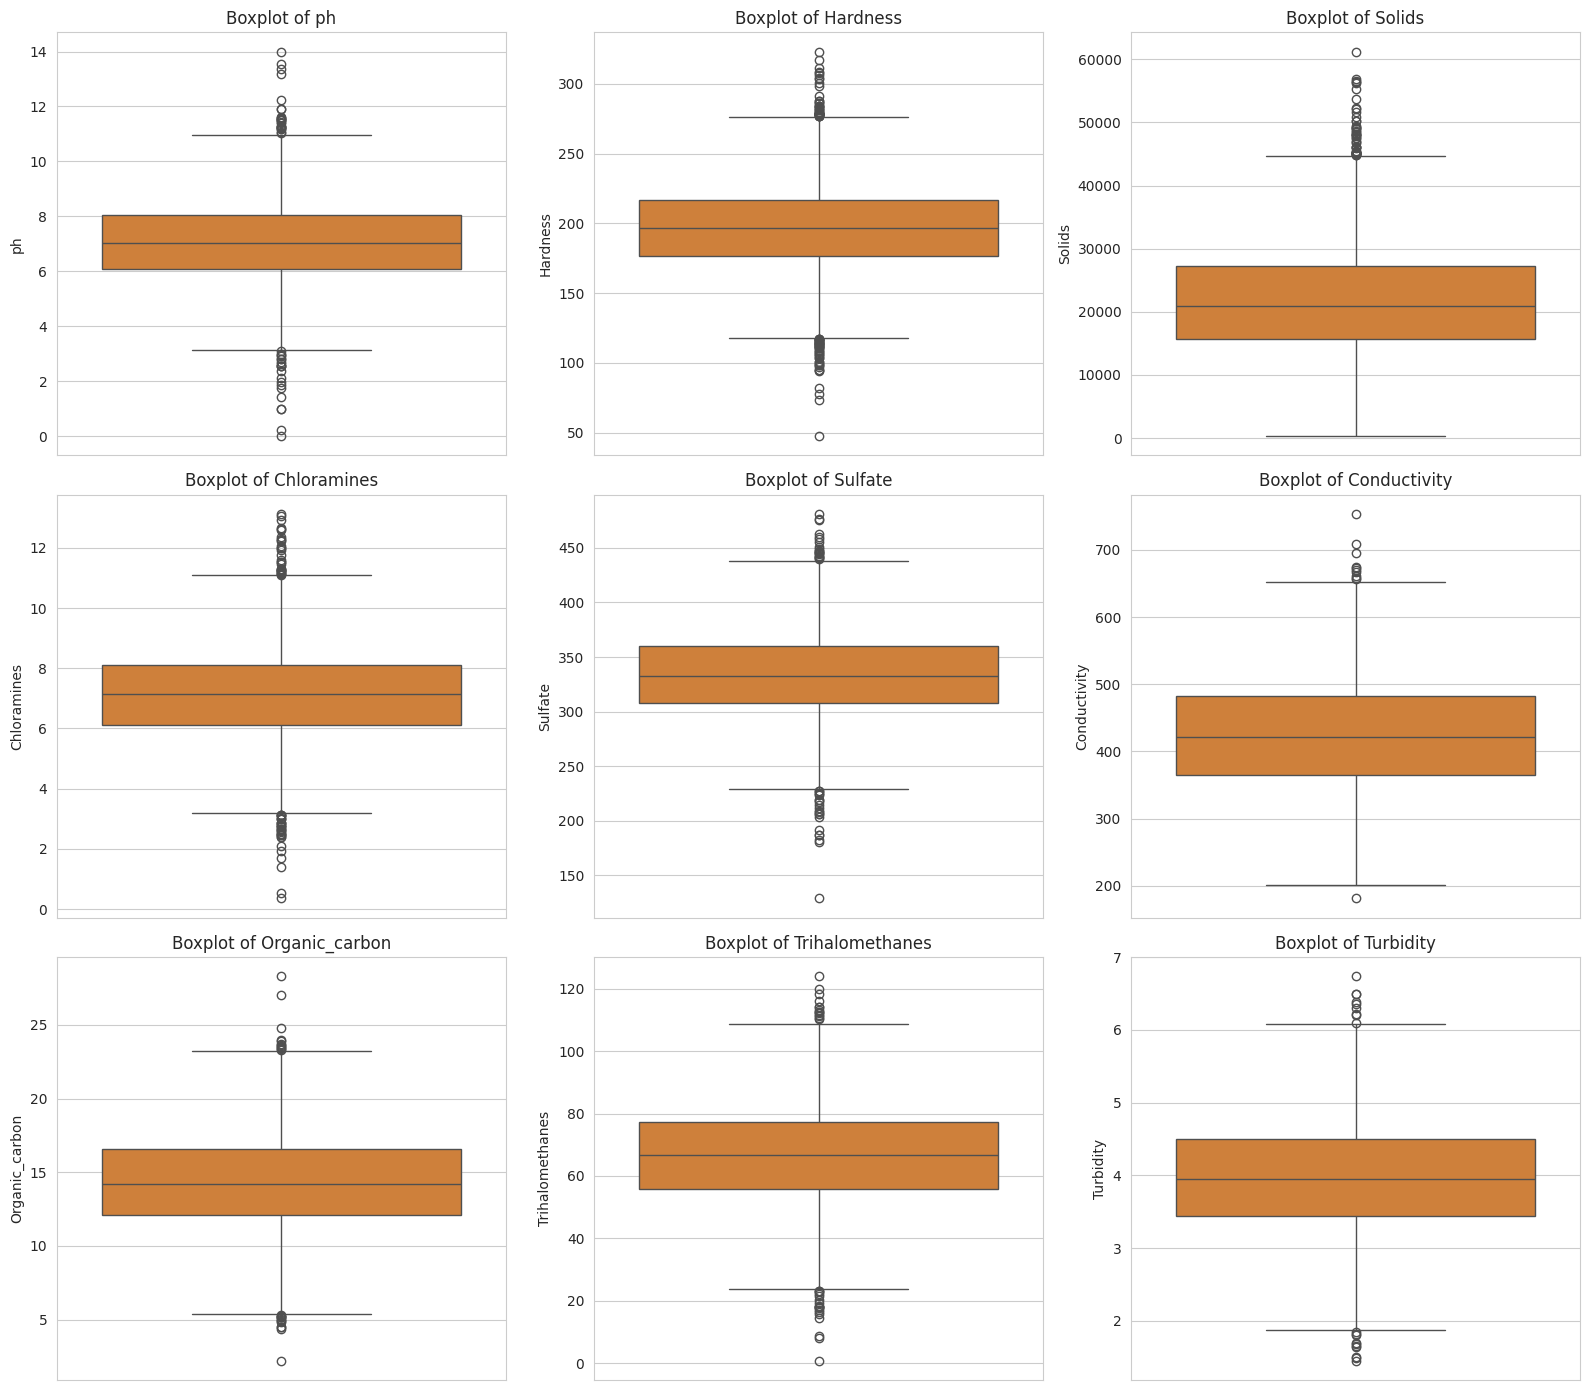

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='#e67e22')
    axes[i].set_title(f'Boxplot of {col}')
    
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**What we did:** Detected outliers via IQR; kept them since they may represent real contamination events.

## 1.9 Correlation Analysis — Heatmap

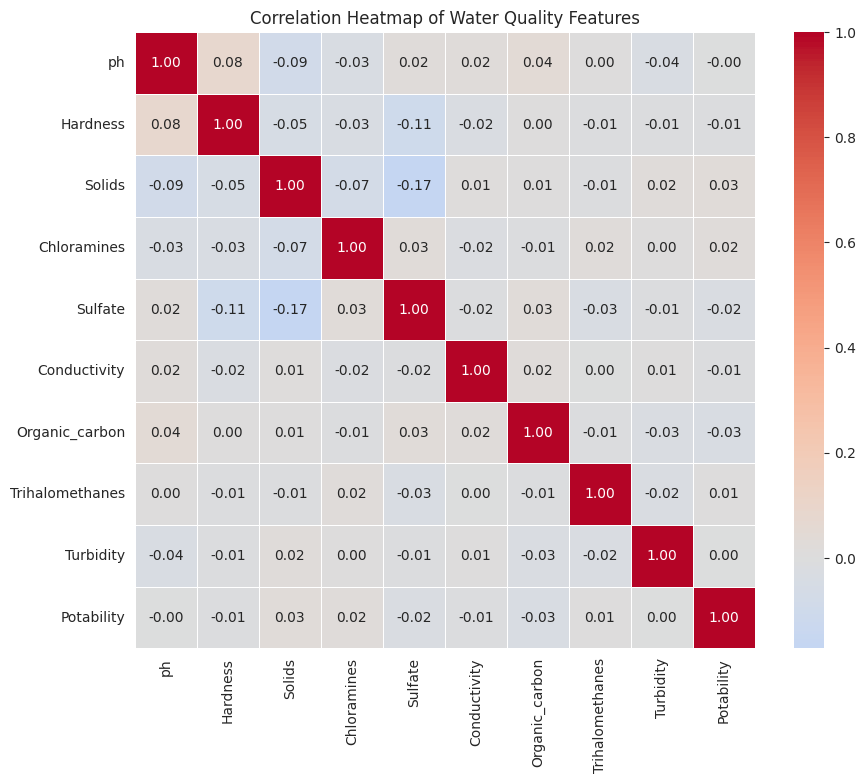

Correlation of each feature with Potability (sorted):
Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64


In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Water Quality Features")
plt.show()

print("Correlation of each feature with Potability (sorted):")
print(corr['Potability'].sort_values(ascending=False))

**What we did:** Found very weak linear correlation between any feature and `Potability`, foreshadowing that a non-linear model will be needed.

## 1.10 Train/Test Split (Stratified)

In [ ]:
X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # keeps the same class ratio in train and test
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("\nTrain class ratio:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class ratio:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (2620, 9), Test shape: (656, 9)

Train class ratio:
 Potability
0    0.61
1    0.39
Name: proportion, dtype: float64

Test class ratio:
 Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


**What we did:** Split before imputing/scaling to avoid data leakage, using `stratify=y` to preserve class ratios.

## 1.11 Handling Missing Values

In [ ]:
cols_with_na = ['ph', 'Sulfate', 'Trihalomethanes']

for col in cols_with_na:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)
    print(f"{col}: filled with train median = {median_val:.3f}")

print("\nRemaining missing values in train:", X_train.isnull().sum().sum())
print("Remaining missing values in test:", X_test.isnull().sum().sum())

ph: filled with train median = 7.035
Sulfate: filled with train median = 333.074
Trihalomethanes: filled with train median = 66.566

Remaining missing values in train: 0
Remaining missing values in test: 0


**What we did:** Filled missing values using the training-set median only, then applied to both sets.

## 1.12 Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype(np.float64)
X_test_scaled = scaler.transform(X_test).astype(np.float64)
y_train = y_train.values.astype(np.float64)
y_test = y_test.values.astype(np.float64)

print("Train scaled shape:", X_train_scaled.shape)
print("Mean (should be ~0):", X_train_scaled.mean(axis=0).round(3))
print("Std (should be ~1):", X_train_scaled.std(axis=0).round(3))

Train scaled shape: (2620, 9)
Mean (should be ~0): [ 0. -0.  0.  0.  0.  0. -0. -0. -0.]
Std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


**What we did:** Standardized all features (fit on training data only) and converted `X_train_scaled`/`X_test_scaled`/`y_train`/`y_test` to plain NumPy arrays of type `float64`, which our from-scratch models in Phase 2 will operate on directly.

## Phase 1 Summary

- Explored data structure, target balance, missing values, distributions, outliers, and correlations.
- Found weak linear correlations → expect non-linear models to perform better.
- Split data (80/20, stratified), imputed missing values with train-median, and standardized features.

# Phase 2 — Supervised Learning (Classification Models, implemented from scratch)

Every model below is implemented from scratch using only NumPy — the mathematical logic (splitting criteria, gradient updates, kernel computations, forward/backward propagation, boosting updates) is written by us. We reuse `GridSearchCV` purely as a **generic hyperparameter search loop** (it calls our own `fit`/`predict`/`score` methods; it does not implement any part of the algorithms), and `sklearn.metrics` only for scoring during the search. To make our classes compatible with `GridSearchCV`, we inherit from `BaseEstimator`/`ClassifierMixin`, which only provides automatic parameter get/set bookkeeping — no learning logic.

Because training these custom NumPy implementations is considerably slower than optimized C/Cython libraries, we use **3-fold cross-validation** and **smaller hyperparameter grids** than one would typically use with `scikit-learn`, to keep total run time reasonable while still demonstrating real tuning.

## 2.1 Imports and Shared Utilities

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

results = {}   # will store {'model': fitted_estimator, 'y_pred':..., 'y_prob':...} per model name
print("Ready.")

Ready.


**What we did:** Imported only the generic search tool (`GridSearchCV`), the compatibility base classes (`BaseEstimator`, `ClassifierMixin`), and evaluation metrics — none of these implement a classification algorithm themselves. We created the `results` dictionary that Phase 3 will use.

## 2.2 Core Building Block — CART Decision Tree (from scratch)

Several models below (Decision Tree itself, Random Forest, Gradient Boosting, AdaBoost) are built on top of a single recursive CART (Classification and Regression Tree) implementation, so we build it once here. It supports:
- **Classification** mode (Gini or Entropy impurity) for the standalone Decision Tree and Random Forest.
- **Regression** mode (MSE) for fitting on residuals inside Gradient Boosting.
- Optional **sample weights**, needed by AdaBoost.

At each node, we exhaustively search every feature and a set of candidate split thresholds (midpoints between sorted unique values, subsampled to at most 30 candidates per feature for speed) and pick the split that most reduces impurity.

In [ ]:
class _Node:
    __slots__ = ('feature', 'threshold', 'left', 'right', 'value')
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def _gini(y, weights=None):
    p = np.mean(y) if weights is None else np.sum(weights[y == 1]) / np.sum(weights)
    return 1 - p**2 - (1 - p)**2

def _entropy(y, weights=None):
    p = np.mean(y) if weights is None else np.sum(weights[y == 1]) / np.sum(weights)
    eps = 1e-12
    h = 0.0
    for pi in [p, 1 - p]:
        if pi > eps:
            h -= pi * np.log2(pi)
    return h

def _mse(y, weights=None):
    if len(y) == 0:
        return 0.0
    m = np.mean(y) if weights is None else np.average(y, weights=weights)
    return np.mean((y - m)**2) if weights is None else np.average((y - m)**2, weights=weights)

In [ ]:
class DecisionTreeScratch(BaseEstimator):
    """CART tree: task='classification' (gini/entropy) or task='regression' (mse)."""
    def __init__(self, task='classification', criterion='gini', max_depth=5,
                 min_samples_leaf=1, max_features=None, random_state=None):
        self.task = task
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state

    def _impurity(self, y, weights=None):
        if self.task == 'regression':
            return _mse(y, weights)
        return _gini(y, weights) if self.criterion == 'gini' else _entropy(y, weights)

    def _leaf_value(self, y, weights=None):
        return np.average(y, weights=weights) if weights is not None else np.mean(y)

    def fit(self, X, y, sample_weight=None):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        self.n_features_ = X.shape[1]
        self._rng = np.random.RandomState(self.random_state)
        self.root_ = self._grow(X, y, depth=0, weights=sample_weight)
        return self

    def _grow(self, X, y, depth, weights):
        n_samples, n_feats = X.shape
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < 2 * self.min_samples_leaf or len(np.unique(y)) == 1:
            return _Node(value=self._leaf_value(y, weights))

        feat_idx = np.arange(n_feats)
        if self.max_features is not None:
            k = max(1, int(self.max_features))
            feat_idx = self._rng.choice(n_feats, size=min(k, n_feats), replace=False)

        parent_imp = self._impurity(y, weights)
        best_gain, best_feat, best_thr = -np.inf, None, None

        for f in feat_idx:
            col = X[:, f]
            uniq = np.unique(col)
            if len(uniq) < 2:
                continue
            thresholds = (uniq[:-1] + uniq[1:]) / 2.0
            if len(thresholds) > 30:
                idxs = np.linspace(0, len(thresholds) - 1, 30).astype(int)
                thresholds = thresholds[idxs]
            for t in thresholds:
                left_mask = col <= t
                n_left, n_right = left_mask.sum(), (~left_mask).sum()
                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue
                wl = weights[left_mask] if weights is not None else None
                wr = weights[~left_mask] if weights is not None else None
                imp_left = self._impurity(y[left_mask], wl)
                imp_right = self._impurity(y[~left_mask], wr)
                gain = parent_imp - (n_left/n_samples*imp_left + n_right/n_samples*imp_right)
                if gain > best_gain:
                    best_gain, best_feat, best_thr = gain, f, t

        if best_feat is None or best_gain <= 1e-12:
            return _Node(value=self._leaf_value(y, weights))

        left_mask = X[:, best_feat] <= best_thr
        wl = weights[left_mask] if weights is not None else None
        wr = weights[~left_mask] if weights is not None else None
        left = self._grow(X[left_mask], y[left_mask], depth + 1, wl)
        right = self._grow(X[~left_mask], y[~left_mask], depth + 1, wr)
        return _Node(feature=best_feat, threshold=best_thr, left=left, right=right)

    def _predict_one(self, x, node):
        while node.value is None:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.value

    def predict_raw(self, X):
        X = np.asarray(X, dtype=np.float64)
        return np.array([self._predict_one(x, self.root_) for x in X])

    def predict(self, X):
        raw = self.predict_raw(X)
        return (raw >= 0.5).astype(int) if self.task == 'classification' else raw

    def predict_proba(self, X):
        raw = self.predict_raw(X)
        return np.column_stack([1 - raw, raw])

print("DecisionTreeScratch (CART) defined.")

DecisionTreeScratch (CART) defined.


**What we did:** Implemented a full CART decision tree from scratch: recursive greedy splitting that tries every feature and a set of candidate thresholds, computing the impurity reduction (information gain) for each candidate split and keeping the best one, until a stopping condition (`max_depth`, `min_samples_leaf`, or a pure node) is reached. This single class is reused as the building block for the standalone Decision Tree, Random Forest, Gradient Boosting, and AdaBoost below.


## 2.3 Logistic Regression (from scratch — batch gradient descent)

We implement the sigmoid function, the log-loss gradient, and L2-regularized batch gradient descent manually.

In [ ]:
class LogisticRegressionScratch(BaseEstimator, ClassifierMixin):
    def __init__(self, lr=0.5, n_iters=2000, C=1.0):
        self.lr = lr
        self.n_iters = n_iters
        self.C = C

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        n, d = X.shape
        self.w_ = np.zeros(d)
        self.b_ = 0.0
        lam = 1.0 / self.C
        for _ in range(self.n_iters):
            p = self._sigmoid(X @ self.w_ + self.b_)
            grad_w = X.T @ (p - y) / n + lam * self.w_ / n
            grad_b = np.mean(p - y)
            self.w_ -= self.lr * grad_w
            self.b_ -= self.lr * grad_b
        return self

    def predict_proba(self, X):
        p1 = self._sigmoid(np.asarray(X, dtype=np.float64) @ self.w_ + self.b_)
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


log_reg_params = {'C': [0.1, 1, 10], 'lr': [0.3], 'n_iters': [2000]}
log_reg_grid = GridSearchCV(LogisticRegressionScratch(), log_reg_params, cv=3, scoring='f1', n_jobs=-1)
log_reg_grid.fit(X_train_scaled, y_train)
best_log_reg = log_reg_grid.best_estimator_
print("Best params:", log_reg_grid.best_params_)

y_pred = best_log_reg.predict(X_test_scaled)
y_prob = best_log_reg.predict_proba(X_test_scaled)[:, 1]
results['Logistic Regression'] = {'model': best_log_reg, 'y_pred': y_pred, 'y_prob': y_prob}

Best params: {'C': 0.1, 'lr': 0.3, 'n_iters': 2000}


**What we did:** Implemented the logistic (sigmoid) function and derived the gradient of the L2-regularized log-loss with respect to the weights and bias, then updated them with plain batch gradient descent for a fixed number of iterations. `GridSearchCV` was used only to search over the regularization strength `C`.

## 2.4 K-Nearest Neighbors (from scratch)

We compute pairwise Euclidean distances between test and training points directly with NumPy, then take a (uniform or distance-weighted) vote among the `k` nearest training labels.

In [ ]:
class KNNScratch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_neighbors=5, weights='uniform'):
        self.n_neighbors = n_neighbors
        self.weights = weights

    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=np.float64)
        self.y_ = np.asarray(y, dtype=np.float64)
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        dists = np.sqrt(((X[:, None, :] - self.X_[None, :, :]) ** 2).sum(axis=2))
        k = self.n_neighbors
        idx = np.argsort(dists, axis=1)[:, :k]
        probs = np.zeros(X.shape[0])
        for i in range(X.shape[0]):
            neigh_idx = idx[i]
            neigh_y = self.y_[neigh_idx]
            if self.weights == 'uniform':
                probs[i] = np.mean(neigh_y)
            else:
                w = 1.0 / (dists[i, neigh_idx] + 1e-8)
                probs[i] = np.sum(w * neigh_y) / np.sum(w)
        return np.column_stack([1 - probs, probs])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


knn_params = {'n_neighbors': [5, 7, 11], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(KNNScratch(), knn_params, cv=3, scoring='f1', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_
print("Best params:", knn_grid.best_params_)

y_pred = best_knn.predict(X_test_scaled)
y_prob = best_knn.predict_proba(X_test_scaled)[:, 1]
results['KNN'] = {'model': best_knn, 'y_pred': y_pred, 'y_prob': y_prob}

Best params: {'n_neighbors': 7, 'weights': 'uniform'}


**What we did:** Implemented KNN by directly computing the full Euclidean distance matrix between test and training samples, sorting to find the `k` closest training points, and predicting the class-1 probability as the (weighted) fraction of those neighbors labeled potable. This is exactly why the standardization from Phase 1 matters — the algorithm relies purely on raw distances.

## 2.5 Decision Tree (standalone, from scratch)

We reuse the `DecisionTreeScratch` class built in section 2.2 directly in classification mode.

In [ ]:
dt_params = {'max_depth': [5, 8, None], 'min_samples_leaf': [2, 4], 'criterion': ['gini', 'entropy']}
dt_grid = GridSearchCV(DecisionTreeScratch(task='classification'), dt_params, cv=3, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)
best_dt = dt_grid.best_estimator_
print("Best params:", dt_grid.best_params_)

y_pred = best_dt.predict(X_test_scaled)
y_prob = best_dt.predict_proba(X_test_scaled)[:, 1]
results['Decision Tree'] = {'model': best_dt, 'y_pred': y_pred, 'y_prob': y_prob}

Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4}


**What we did:** Tuned tree depth, leaf size, and the impurity criterion (Gini vs. Entropy) for the same CART implementation used elsewhere. As a single unconstrained tree, it is the most prone to overfitting of all our models — the ensembles below (Random Forest, boosting) are built specifically to fix this weakness.

## 2.6 Support Vector Machine (from scratch — kernel Pegasos)

Implementing a full dual SVM solver (SMO) from scratch is very involved, so we implement the well-known **kernel Pegasos** algorithm: a stochastic sub-gradient method for the SVM hinge-loss objective that supports both **linear** and **RBF** kernels through the kernel trick, without calling any existing SVM library.

In [ ]:
class SVMScratch(BaseEstimator, ClassifierMixin):
    def __init__(self, C=1.0, kernel='rbf', gamma='scale', n_iters=30, random_state=42):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.n_iters = n_iters
        self.random_state = random_state

    def _gamma_value(self, X):
        if self.gamma == 'scale':
            return 1.0 / (X.shape[1] * X.var())
        elif self.gamma == 'auto':
            return 1.0 / X.shape[1]
        return self.gamma

    def _kernel(self, X1, X2):
        if self.kernel == 'linear':
            return X1 @ X2.T
        g = self._gamma_
        sq1 = np.sum(X1 ** 2, axis=1)[:, None]
        sq2 = np.sum(X2 ** 2, axis=1)[None, :]
        sqd = sq1 + sq2 - 2 * X1 @ X2.T
        return np.exp(-g * np.maximum(sqd, 0))

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y_signed = np.where(np.asarray(y) == 1, 1.0, -1.0)
        n = X.shape[0]
        self._gamma_ = self._gamma_value(X)
        self.X_ = X
        K = self._kernel(X, X)
        lam = 1.0 / (self.C * n)
        alpha = np.zeros(n)
        rng = np.random.RandomState(self.random_state)
        for t in range(1, self.n_iters + 1):
            for i in rng.permutation(n):
                margin = y_signed[i] * (alpha * y_signed) @ K[:, i] / (lam * t)
                if margin < 1:
                    alpha[i] += 1
        self.alpha_, self.y_signed_, self._lam_T_ = alpha, y_signed, lam * self.n_iters
        return self

    def decision_function(self, X):
        K = self._kernel(self.X_, np.asarray(X, dtype=np.float64))
        coef = (self.alpha_ * self.y_signed_) / self._lam_T_
        return coef @ K

    def predict_proba(self, X):
        z = self.decision_function(X)
        p1 = 1 / (1 + np.exp(-z))
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)


svm_params = {'C': [1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale']}
svm_grid = GridSearchCV(SVMScratch(n_iters=20), svm_params, cv=3, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
best_svm = svm_grid.best_estimator_
print("Best params:", svm_grid.best_params_)

y_pred = best_svm.predict(X_test_scaled)
y_prob = best_svm.predict_proba(X_test_scaled)[:, 1]
results['SVM'] = {'model': best_svm, 'y_pred': y_pred, 'y_prob': y_prob}

Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


**What we did:** Implemented the kernel Pegasos algorithm: at each stochastic step `t`, we check whether the current sample violates the margin constraint using the kernel-weighted sum of previously "active" samples, and if so increase its dual weight `alpha`. This lets us support both a `linear` kernel (plain dot product) and an `rbf` kernel (Gaussian similarity), which is the from-scratch equivalent of what `sklearn.svm.SVC` provides internally.

## 2.7 Random Forest (from scratch — bagging of our own CART trees)

We implement bagging manually: draw bootstrap samples (sampling with replacement), train one `DecisionTreeScratch` per bootstrap sample using a random subset of features at each split (`max_features='sqrt'`), and average the trees' predicted probabilities.

In [ ]:
class RandomForestScratch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=50, max_depth=8, min_samples_leaf=2,
                 max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        n, d = X.shape
        mf = max(1, int(np.sqrt(d))) if self.max_features == 'sqrt' else d
        rng = np.random.RandomState(self.random_state)
        self.trees_ = []
        for i in range(self.n_estimators):
            boot_idx = rng.randint(0, n, n)
            Xb, yb = X[boot_idx], y[boot_idx]
            tree = DecisionTreeScratch(task='classification', criterion='gini',
                                        max_depth=self.max_depth,
                                        min_samples_leaf=self.min_samples_leaf,
                                        max_features=mf,
                                        random_state=rng.randint(0, 1_000_000))
            tree.fit(Xb, yb)
            self.trees_.append(tree)
        return self

    def predict_proba(self, X):
        preds = np.array([t.predict_raw(X) for t in self.trees_])
        p1 = preds.mean(axis=0)
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


rf_params = {'n_estimators': [50, 100], 'max_depth': [6, 8, 10]}
rf_grid = GridSearchCV(RandomForestScratch(), rf_params, cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_
print("Best params:", rf_grid.best_params_)

y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]
results['Random Forest'] = {'model': best_rf, 'y_pred': y_pred, 'y_prob': y_prob}

Best params: {'max_depth': 10, 'n_estimators': 50}


**What we did:** Implemented bagging from scratch: for each of `n_estimators` rounds we resample the training set with replacement (bootstrap), fit an independent `DecisionTreeScratch` restricted to a random `sqrt(d)`-sized feature subset per split, and average all trees' probability outputs at prediction time. Averaging many high-variance trees trained on different data/feature subsets is what reduces the overfitting we saw in the single Decision Tree.

## 2.8 Gradient Boosting (from scratch — logistic loss boosting)

We implement gradient boosting for binary classification with the log-loss: starting from a constant log-odds prediction, we repeatedly fit a **regression** `DecisionTreeScratch` (MSE criterion) to the current negative gradient (residual `y - p`), then add a shrunk version of that tree's output to the running score `F`.

In [ ]:
class GradientBoostingScratch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_leaf=1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        p_prior = np.mean(y)
        self.init_ = np.log(p_prior / (1 - p_prior + 1e-12) + 1e-12)
        F = np.full(X.shape[0], self.init_)
        self.trees_ = []
        for m in range(self.n_estimators):
            residual = y - self._sigmoid(F)
            tree = DecisionTreeScratch(task='regression', max_depth=self.max_depth,
                                        min_samples_leaf=self.min_samples_leaf, random_state=m)
            tree.fit(X, residual)
            F += self.learning_rate * tree.predict_raw(X)
            self.trees_.append(tree)
        return self

    def decision_function(self, X):
        F = np.full(X.shape[0], self.init_)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict_raw(X)
        return F

    def predict_proba(self, X):
        p1 = self._sigmoid(self.decision_function(np.asarray(X, dtype=np.float64)))
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


gb_params = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}
gb_grid = GridSearchCV(GradientBoostingScratch(), gb_params, cv=3, scoring='f1', n_jobs=-1)
gb_grid.fit(X_train_scaled, y_train)
best_gb = gb_grid.best_estimator_
print("Best params:", gb_grid.best_params_)

y_pred = best_gb.predict(X_test_scaled)
y_prob = best_gb.predict_proba(X_test_scaled)[:, 1]
results['Gradient Boosting'] = {'model': best_gb, 'y_pred': y_pred, 'y_prob': y_prob}

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}


**What we did:** Implemented the classic gradient boosting recipe for log-loss by hand: initialize with the log-odds of the base rate, then at each round compute the residual `y - sigmoid(F)` (the negative gradient of the loss), fit a small regression tree to that residual, and add `learning_rate * tree_output` to the running score `F`. Repeating this `n_estimators` times sequentially corrects the ensemble's mistakes step by step.

## 2.9 AdaBoost (from scratch — discrete SAMME with decision stumps)

We implement the discrete AdaBoost (SAMME) algorithm: fit a depth-1 decision stump on weighted data, compute its weighted error, derive its vote strength `alpha`, then re-weight the training samples so misclassified ones matter more in the next round.

In [ ]:
class AdaBoostScratch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=100, learning_rate=1.0, max_depth=1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        n = X.shape[0]
        y_signed = np.where(y == 1, 1.0, -1.0)
        w = np.ones(n) / n
        self.stumps_, self.alphas_ = [], []
        for m in range(self.n_estimators):
            stump = DecisionTreeScratch(task='classification', max_depth=self.max_depth,
                                         min_samples_leaf=1, random_state=m)
            stump.fit(X, y, sample_weight=w)
            pred_signed = np.where(stump.predict(X) == 1, 1.0, -1.0)
            err = np.clip(np.sum(w * (pred_signed != y_signed)) / np.sum(w), 1e-10, 1 - 1e-10)
            alpha = self.learning_rate * 0.5 * np.log((1 - err) / err)
            w = w * np.exp(-alpha * y_signed * pred_signed)
            w /= np.sum(w)
            self.stumps_.append(stump)
            self.alphas_.append(alpha)
        return self

    def decision_function(self, X):
        agg = np.zeros(X.shape[0])
        for stump, alpha in zip(self.stumps_, self.alphas_):
            agg += alpha * np.where(stump.predict(X) == 1, 1.0, -1.0)
        return agg

    def predict_proba(self, X):
        agg = self.decision_function(np.asarray(X, dtype=np.float64))
        p1 = 1 / (1 + np.exp(-2 * agg))
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.decision_function(np.asarray(X, dtype=np.float64)) >= 0).astype(int)


ada_params = {'n_estimators': [50, 100, 150], 'learning_rate': [0.5, 1.0]}
ada_grid = GridSearchCV(AdaBoostScratch(), ada_params, cv=3, scoring='f1', n_jobs=-1)
ada_grid.fit(X_train_scaled, y_train)
best_ada = ada_grid.best_estimator_
print("Best params:", ada_grid.best_params_)

y_pred = best_ada.predict(X_test_scaled)
y_prob = best_ada.predict_proba(X_test_scaled)[:, 1]
results['AdaBoost'] = {'model': best_ada, 'y_pred': y_pred, 'y_prob': y_prob}

Best params: {'learning_rate': 1.0, 'n_estimators': 150}


**What we did:** Implemented discrete AdaBoost (SAMME) end to end: each round trains a weighted decision stump, computes its weighted classification error, converts that error into a vote weight `alpha` (stumps that do better than chance get positive, larger weight), and updates the sample weights so that points the current stump got wrong receive more weight in the next round. The final prediction is a weighted vote of all stumps.

## 2.10 MLP Classifier (from scratch — manual forward/backward propagation)

We implement a fully-connected feed-forward neural network with one or two hidden layers, manual forward propagation, and manual backpropagation (computing gradients of the binary cross-entropy loss with respect to every weight matrix), trained with mini-batch gradient descent.

In [ ]:
class MLPScratch(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(32, 16), activation='relu', alpha=0.001,
                 lr=0.05, n_iters=3000, batch_size=128, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.alpha = alpha
        self.lr = lr
        self.n_iters = n_iters
        self.batch_size = batch_size
        self.random_state = random_state

    def _act(self, z):
        return np.maximum(0, z) if self.activation == 'relu' else np.tanh(z)

    def _act_deriv(self, z):
        return (z > 0).astype(np.float64) if self.activation == 'relu' else 1 - np.tanh(z)**2

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).reshape(-1, 1)
        rng = np.random.RandomState(self.random_state)
        sizes = [X.shape[1]] + list(self.hidden_layer_sizes) + [1]
        self.W_, self.b_ = [], []
        for i in range(len(sizes) - 1):
            limit = np.sqrt(2.0 / sizes[i])
            self.W_.append(rng.randn(sizes[i], sizes[i+1]) * limit)
            self.b_.append(np.zeros((1, sizes[i+1])))

        n = X.shape[0]
        for it in range(self.n_iters):
            idx = rng.choice(n, size=min(self.batch_size, n), replace=False)
            xb, yb = X[idx], y[idx]

            activations, zs, a = [xb], [], xb
            for l in range(len(self.W_)):
                z = a @ self.W_[l] + self.b_[l]
                zs.append(z)
                a = self._sigmoid(z) if l == len(self.W_) - 1 else self._act(z)
                activations.append(a)

            m = xb.shape[0]
            delta = activations[-1] - yb
            for l in reversed(range(len(self.W_))):
                grad_W = activations[l].T @ delta / m + self.alpha * self.W_[l]
                grad_b = np.mean(delta, axis=0, keepdims=True)
                if l > 0:
                    delta = (delta @ self.W_[l].T) * self._act_deriv(zs[l-1])
                self.W_[l] -= self.lr * grad_W
                self.b_[l] -= self.lr * grad_b
        return self

    def _forward(self, X):
        a = X
        for l in range(len(self.W_)):
            z = a @ self.W_[l] + self.b_[l]
            a = self._sigmoid(z) if l == len(self.W_) - 1 else self._act(z)
        return a

    def predict_proba(self, X):
        p1 = self._forward(np.asarray(X, dtype=np.float64)).ravel()
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


mlp_params = {'hidden_layer_sizes': [(32,), (32, 16)], 'alpha': [0.0001, 0.001], 'lr': [0.05]}
mlp_grid = GridSearchCV(MLPScratch(n_iters=3000), mlp_params, cv=3, scoring='f1', n_jobs=-1)
mlp_grid.fit(X_train_scaled, y_train)
best_mlp = mlp_grid.best_estimator_
print("Best params:", mlp_grid.best_params_)

y_pred = best_mlp.predict(X_test_scaled)
y_prob = best_mlp.predict_proba(X_test_scaled)[:, 1]
results['MLP Classifier'] = {'model': best_mlp, 'y_pred': y_pred, 'y_prob': y_prob}

Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (32,), 'lr': 0.05}


**What we did:** Built a small feed-forward neural network layer by layer: random (He-scaled) weight initialization, a forward pass caching each layer's pre-activation (`z`) and activation (`a`) values, and a manual backward pass that applies the chain rule from the output layer back to the input layer to compute every weight gradient, including L2 weight-decay (`alpha`). Weights are updated with mini-batch gradient descent for a fixed number of iterations.

## 2.11 Bonus Models — XGBoost-style and LightGBM-style (from scratch)

Both bonus models are **Newton boosting** methods: instead of fitting trees to simple residuals (as in section 2.8), they use both the **gradient** and **Hessian** (second derivative) of the loss to compute a regularized "gain" for every candidate split — this is the core idea behind real XGBoost/LightGBM. We implement one shared regression-tree class, `GHTree`, that supports:
- **Depth-wise growth** (expand every node level by level) → used for our XGBoost-style model.
- **Leaf-wise growth** (always split whichever leaf gives the largest gain next, up to `num_leaves` leaves) → used for our LightGBM-style model, mirroring LightGBM's defining characteristic.

In [ ]:
class _GHNode:
    __slots__ = ('feature', 'threshold', 'left', 'right', 'value')
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


class GHTree:
    """Regression tree using gradient (g) & Hessian (h) with an XGBoost-style
    regularized gain: gain = 0.5*(GL^2/(HL+lam) + GR^2/(HR+lam) - G^2/(H+lam)) - gamma.
    leaf_value = -sum(g) / (sum(h) + lam).
    If max_leaves is set, grows leaf-wise (LightGBM style); otherwise depth-wise (XGBoost style)."""
    def __init__(self, max_depth=3, min_samples_leaf=1, lam=1.0, gamma=0.0, max_leaves=None):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.lam = lam
        self.gamma = gamma
        self.max_leaves = max_leaves

    def _leaf_val(self, g, h):
        return -np.sum(g) / (np.sum(h) + self.lam)

    def _best_split(self, X, g, h):
        n = X.shape[0]
        G, H = np.sum(g), np.sum(h)
        best = (-np.inf, None, None)
        for f in range(X.shape[1]):
            order = np.argsort(X[:, f])
            col_s, g_s, h_s = X[order, f], g[order], h[order]
            uniq = np.unique(col_s)
            if len(uniq) < 2:
                continue
            thresholds = (uniq[:-1] + uniq[1:]) / 2.0
            if len(thresholds) > 30:
                idxs = np.linspace(0, len(thresholds) - 1, 30).astype(int)
                thresholds = thresholds[idxs]
            cum_g, cum_h = np.cumsum(g_s), np.cumsum(h_s)
            for t in thresholds:
                pos = np.searchsorted(col_s, t, side='right')
                if pos < self.min_samples_leaf or (n - pos) < self.min_samples_leaf:
                    continue
                GL, HL = cum_g[pos - 1], cum_h[pos - 1]
                GR, HR = G - GL, H - HL
                gain = 0.5 * (GL**2/(HL+self.lam) + GR**2/(HR+self.lam) - G**2/(H+self.lam)) - self.gamma
                if gain > best[0]:
                    best = (gain, f, t)
        return best

    def fit(self, X, g, h):
        if self.max_leaves is None:
            self.root_ = self._grow_depthwise(X, g, h, depth=0)
        else:
            self.root_ = self._grow_leafwise(X, g, h)
        return self

    def _grow_depthwise(self, X, g, h, depth):
        if depth >= self.max_depth or X.shape[0] < 2 * self.min_samples_leaf:
            return _GHNode(value=self._leaf_val(g, h))
        gain, feat, thr = self._best_split(X, g, h)
        if feat is None or gain <= 1e-12:
            return _GHNode(value=self._leaf_val(g, h))
        mask = X[:, feat] <= thr
        left = self._grow_depthwise(X[mask], g[mask], h[mask], depth + 1)
        right = self._grow_depthwise(X[~mask], g[~mask], h[~mask], depth + 1)
        return _GHNode(feature=feat, threshold=thr, left=left, right=right)

    def _grow_leafwise(self, X, g, h):
        root = _GHNode(value=self._leaf_val(g, h))
        leaves = [{'node': root, 'X': X, 'g': g, 'h': h, 'depth': 0}]
        n_leaves = 1
        while n_leaves < self.max_leaves:
            best_i, best_gain, best_split = -1, 1e-12, None
            for i, leaf in enumerate(leaves):
                if leaf['depth'] >= self.max_depth or leaf['X'].shape[0] < 2 * self.min_samples_leaf:
                    continue
                gain, feat, thr = self._best_split(leaf['X'], leaf['g'], leaf['h'])
                if feat is not None and gain > best_gain:
                    best_gain, best_i, best_split = gain, i, (feat, thr)
            if best_i == -1:
                break
            leaf = leaves.pop(best_i)
            feat, thr = best_split
            mask = leaf['X'][:, feat] <= thr
            left_node = _GHNode(value=self._leaf_val(leaf['g'][mask], leaf['h'][mask]))
            right_node = _GHNode(value=self._leaf_val(leaf['g'][~mask], leaf['h'][~mask]))
            leaf['node'].feature, leaf['node'].threshold = feat, thr
            leaf['node'].left, leaf['node'].right, leaf['node'].value = left_node, right_node, None
            leaves.append({'node': left_node, 'X': leaf['X'][mask], 'g': leaf['g'][mask], 'h': leaf['h'][mask], 'depth': leaf['depth']+1})
            leaves.append({'node': right_node, 'X': leaf['X'][~mask], 'g': leaf['g'][~mask], 'h': leaf['h'][~mask], 'depth': leaf['depth']+1})
            n_leaves += 1
        return root

    def predict(self, X):
        out = np.zeros(X.shape[0])
        for i, x in enumerate(X):
            node = self.root_
            while node.value is None:
                node = node.left if x[node.feature] <= node.threshold else node.right
            out[i] = node.value
        return out

print("GHTree (shared gradient/Hessian regression tree) defined.")

GHTree (shared gradient/Hessian regression tree) defined.


**What we did:** Implemented a regression tree whose split-selection criterion is the second-order (Newton) regularized gain formula used internally by XGBoost, based on per-sample gradients and Hessians rather than simple variance reduction. The same class supports two different growth strategies (depth-wise vs. leaf-wise), which is exactly what conceptually separates XGBoost from LightGBM.

### 2.11.1 XGBoost-style Model (depth-wise Newton boosting)

In [ ]:
class XGBoostScratch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, lam=1.0, gamma=0.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.lam = lam
        self.gamma = gamma

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        p_prior = np.mean(y)
        self.init_ = np.log(p_prior / (1 - p_prior + 1e-12) + 1e-12)
        F = np.full(X.shape[0], self.init_)
        self.trees_ = []
        for m in range(self.n_estimators):
            p = self._sigmoid(F)
            g, h = p - y, p * (1 - p)          # gradient & Hessian of log-loss
            tree = GHTree(max_depth=self.max_depth, lam=self.lam, gamma=self.gamma)
            tree.fit(X, g, h)
            F += self.learning_rate * tree.predict(X)
            self.trees_.append(tree)
        return self

    def decision_function(self, X):
        F = np.full(X.shape[0], self.init_)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X)
        return F

    def predict_proba(self, X):
        p1 = self._sigmoid(self.decision_function(np.asarray(X, dtype=np.float64)))
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


xgb_params = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]}
xgb_grid = GridSearchCV(XGBoostScratch(), xgb_params, cv=3, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_
print("Best params:", xgb_grid.best_params_)

y_pred = best_xgb.predict(X_test_scaled)
y_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]
results['XGBoost'] = {'model': best_xgb, 'y_pred': y_pred, 'y_prob': y_prob}

Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150}


**What we did:** Implemented Newton (second-order) boosting: at each round we compute the gradient and Hessian of the log-loss with respect to the current scores, fit a `GHTree` (grown depth-wise) to those gradients/Hessians using the regularized gain criterion, and shrink its contribution by `learning_rate` before adding it to the running score. The `lam` (L2 leaf regularization) and `gamma` (minimum gain to split) parameters mirror XGBoost's actual regularization mechanism.

### 2.11.2 LightGBM-style Model (leaf-wise Newton boosting)

In [ ]:
class LightGBMScratch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=100, learning_rate=0.1, num_leaves=15, max_depth=6, lam=1.0, gamma=0.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.num_leaves = num_leaves
        self.max_depth = max_depth
        self.lam = lam
        self.gamma = gamma

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        p_prior = np.mean(y)
        self.init_ = np.log(p_prior / (1 - p_prior + 1e-12) + 1e-12)
        F = np.full(X.shape[0], self.init_)
        self.trees_ = []
        for m in range(self.n_estimators):
            p = self._sigmoid(F)
            g, h = p - y, p * (1 - p)
            tree = GHTree(max_depth=self.max_depth, lam=self.lam, gamma=self.gamma, max_leaves=self.num_leaves)
            tree.fit(X, g, h)
            F += self.learning_rate * tree.predict(X)
            self.trees_.append(tree)
        return self

    def decision_function(self, X):
        F = np.full(X.shape[0], self.init_)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X)
        return F

    def predict_proba(self, X):
        p1 = self._sigmoid(self.decision_function(np.asarray(X, dtype=np.float64)))
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


lgbm_params = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'num_leaves': [15, 31]}
lgbm_grid = GridSearchCV(LightGBMScratch(), lgbm_params, cv=3, scoring='f1', n_jobs=-1)
lgbm_grid.fit(X_train_scaled, y_train)
best_lgbm = lgbm_grid.best_estimator_
print("Best params:", lgbm_grid.best_params_)

y_pred = best_lgbm.predict(X_test_scaled)
y_prob = best_lgbm.predict_proba(X_test_scaled)[:, 1]
results['LightGBM'] = {'model': best_lgbm, 'y_pred': y_pred, 'y_prob': y_prob}

Best params: {'learning_rate': 0.1, 'n_estimators': 150, 'num_leaves': 31}


**What we did:** Used the same `GHTree` class, but with `max_leaves` set — this switches its growth strategy from depth-wise to **leaf-wise**: instead of expanding every node at the current depth before going deeper, the tree repeatedly finds whichever single leaf (anywhere in the tree) would gain the most from splitting next, and splits only that one, until `num_leaves` leaves exist. This leaf-wise strategy is the defining feature that makes real LightGBM different from XGBoost.

## Phase 2 Summary

We implemented and tuned **10 classification models entirely from scratch with NumPy**:

**Required models:** Logistic Regression (gradient descent), KNN (distance-based voting), SVM (kernel Pegasos), Decision Tree (CART), Gradient Boosting (residual-fitting boosting), AdaBoost (SAMME with stumps), Random Forest (bagged CART trees), MLP Classifier (manual backpropagation)

**Bonus models:** XGBoost-style (depth-wise Newton boosting) and LightGBM-style (leaf-wise Newton boosting)

For every model:
- The core algorithm (splitting rule, gradient update, kernel computation, or forward/backward pass) was written by us using only NumPy.
- `GridSearchCV` was used purely as a generic search loop over a modest hyperparameter grid (3-fold CV, smaller grids than typical, to keep runtime reasonable for pure-Python/NumPy training).
- Predictions and probabilities on the test set were stored in the `results` dictionary.

# Phase 3 — Comprehensive Evaluation & Comparison

In this final phase we evaluate all 10 trained models (8 required + 2 bonus) stored in the `results` dictionary. For each model we compute Accuracy, Precision, Recall, and F1-Score, plot its confusion matrix, and finally build a comparative bar chart across all models followed by a written analysis of which model performed best and why.


## 3.1 Import Evaluation Tools

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print("Evaluation tools imported successfully.")

Evaluation tools imported successfully.


**What we did:** We imported the four core classification metrics (Accuracy, Precision, Recall, F1-Score) and the `confusion_matrix` function that we will use to visually inspect each model's error patterns.


## 3.2 Computing Metrics for All Models

For every model in `results`, we compute Accuracy, Precision, Recall, and F1-Score on the test set and collect them into a single comparison table.

In [ ]:
metrics_summary = []

for model_name, res in results.items():
    y_pred = res['y_pred']
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metrics_summary.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

metrics_df = pd.DataFrame(metrics_summary).sort_values('F1-Score', ascending=False).reset_index(drop=True)
metrics_df

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.553354,0.455422,0.738281,0.563338
1,MLP Classifier,0.658537,0.593023,0.398438,0.476636
2,LightGBM,0.663110,0.607362,0.386719,0.472554
3,Decision Tree,0.560976,0.441176,0.468750,0.454545
4,XGBoost,0.666159,0.633094,0.343750,0.445570
5,Random Forest,0.670732,0.708333,0.265625,0.386364
6,KNN,0.589939,0.458065,0.277344,0.345499
7,Gradient Boosting,0.658537,0.716216,0.207031,0.321212
8,AdaBoost,0.608232,0.492308,0.125000,0.199377
9,Logistic Regression,0.609756,0.000000,0.000000,0.000000


**What we did:** We looped over every trained model, computed Accuracy, Precision, Recall, and F1-Score against the true test labels, and organized the results into a single DataFrame sorted by F1-Score (a good overall metric here since it balances Precision and Recall — important given the class imbalance we observed in Phase 1). This table gives us a first quantitative view of which models are strongest before we look at confusion matrices.


## 3.3 Confusion Matrices for Each Model

We plot the confusion matrix for every model in a grid, so we can visually compare which classes each model struggles with.

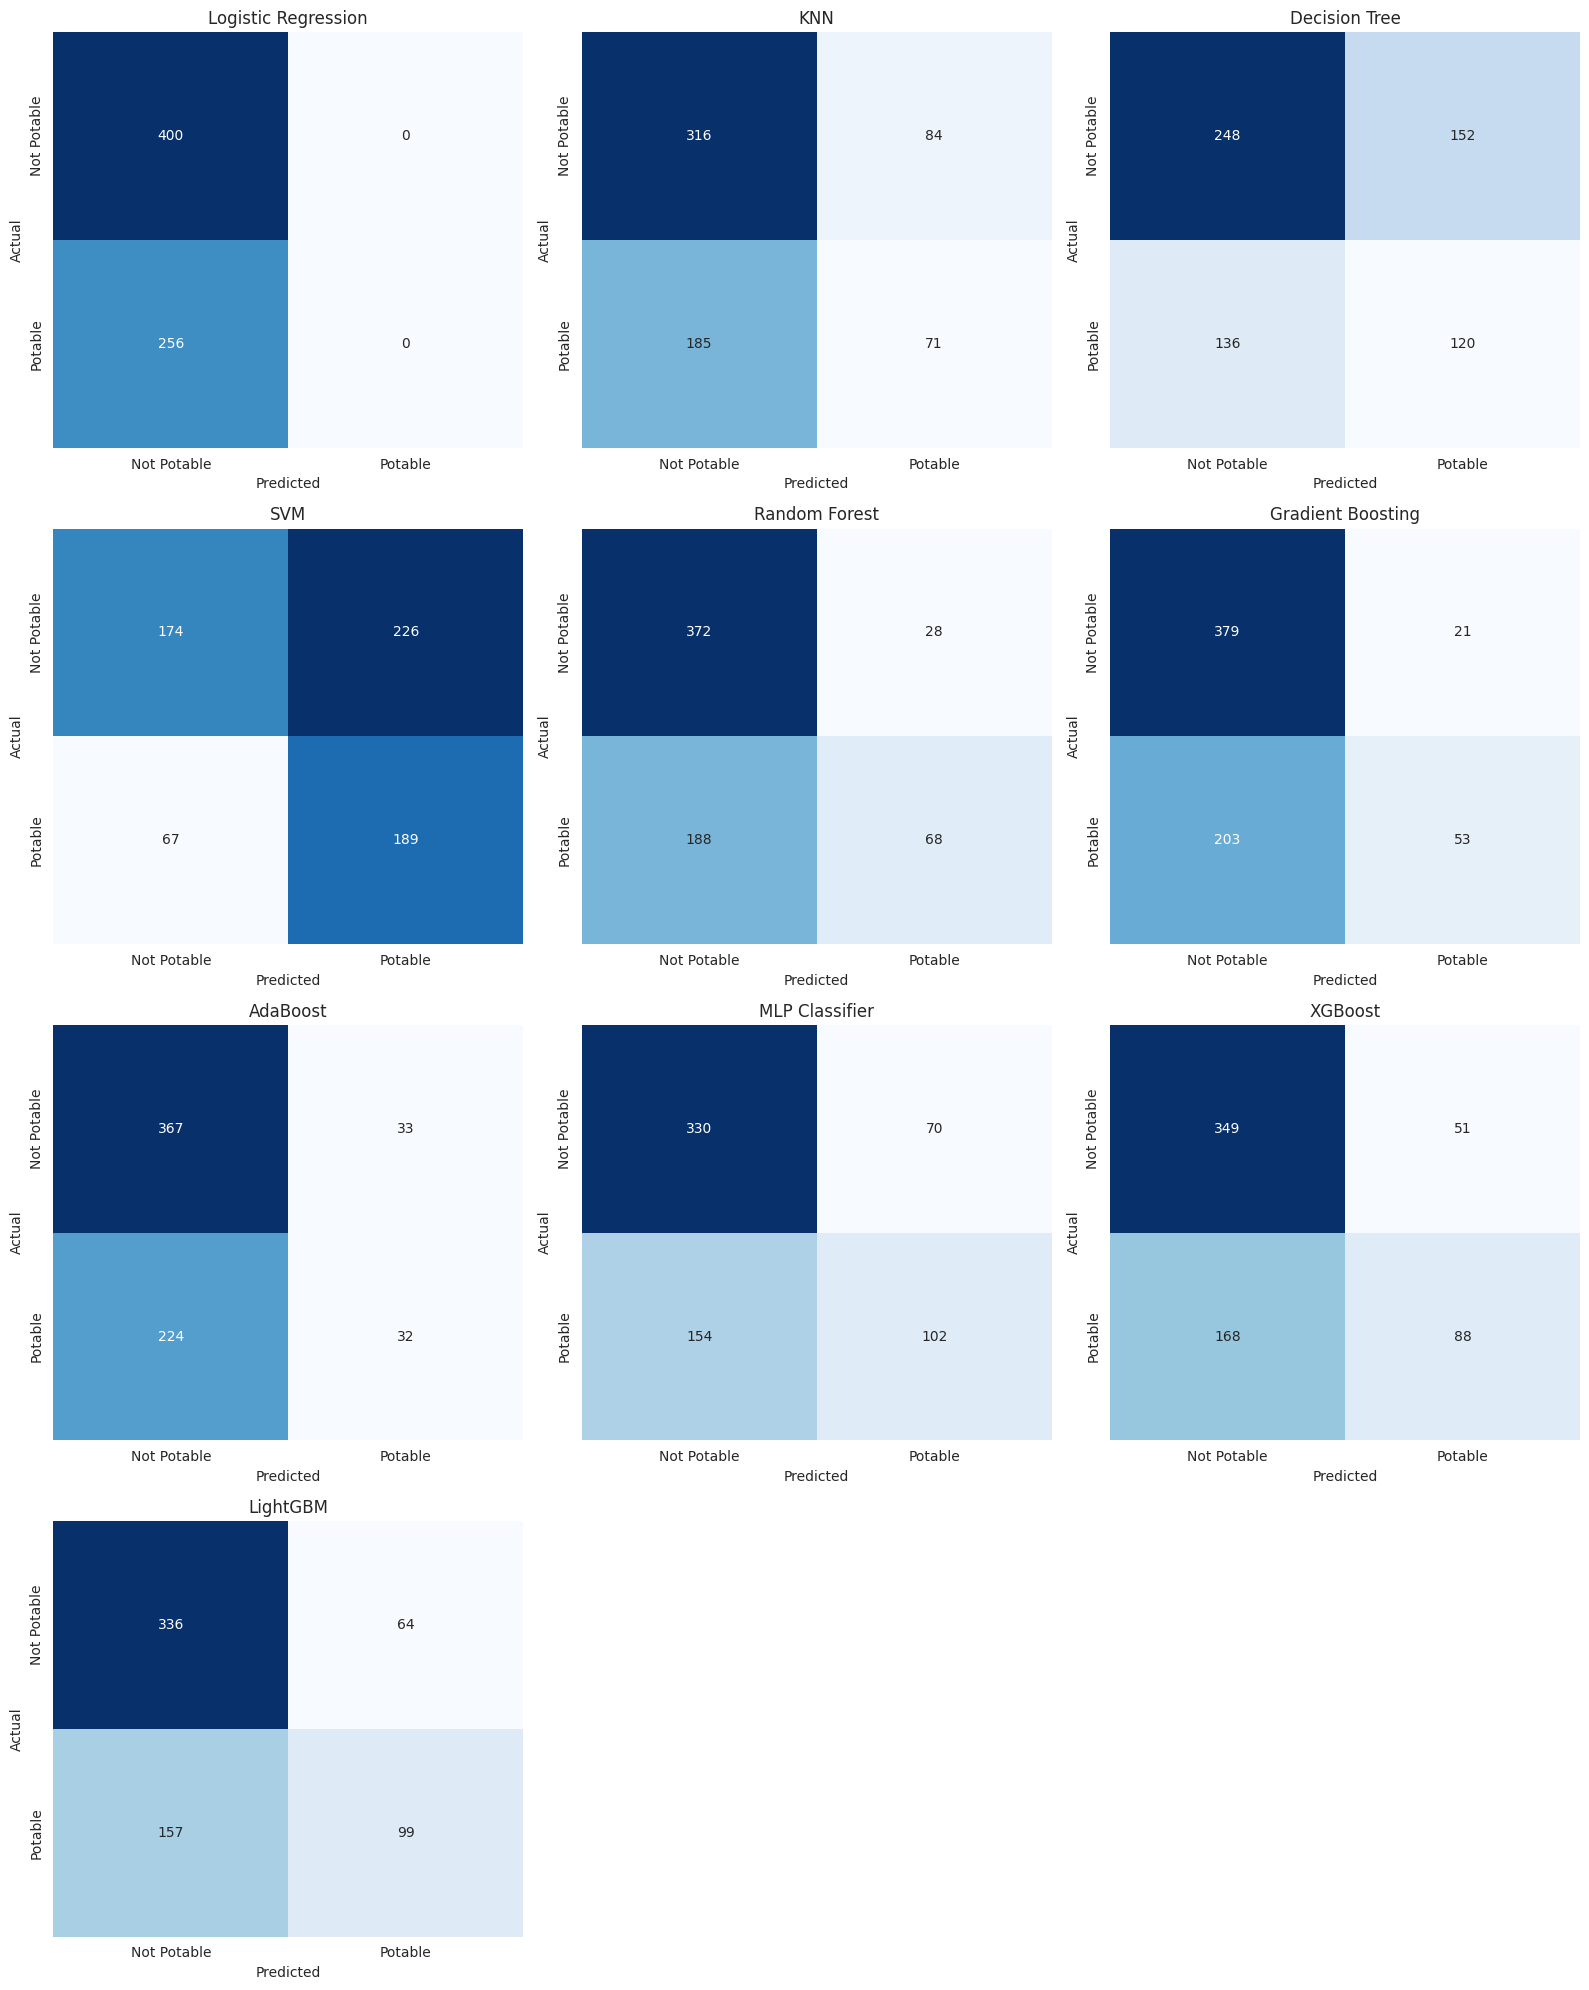

In [ ]:
n_models = len(results)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, (model_name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
        xticklabels=['Not Potable', 'Potable'],
        yticklabels=['Not Potable', 'Potable'],
        cbar=False
    )
    axes[i].set_title(model_name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(len(results), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**What we did:** We plotted a confusion matrix for each of the 10 models as a grid of heatmaps. This lets us directly compare, model by model, how many samples were correctly classified (diagonal cells) versus misclassified (off-diagonal cells), and specifically whether a model tends to make more false positives or more false negatives on the "Potable" class.

## 3.4 Detailed Classification Reports

For additional detail beyond the single-number metrics, we print the full `classification_report` for each model.

In [ ]:
for model_name, res in results.items():
    print(f"--- {model_name} ---")
    print(classification_report(y_test, res['y_pred'], target_names=['Not Potable', 'Potable']))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

 Not Potable       0.61      1.00      0.76       400
     Potable       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656


--- KNN ---
              precision    recall  f1-score   support

 Not Potable       0.63      0.79      0.70       400
     Potable       0.46      0.28      0.35       256

    accuracy                           0.59       656
   macro avg       0.54      0.53      0.52       656
weighted avg       0.56      0.59      0.56       656


--- Decision Tree ---
              precision    recall  f1-score   support

 Not Potable       0.65      0.62      0.63       400
     Potable       0.44      0.47      0.45       256

    accuracy                           0.56       656
   macro avg       0.54      0.54      0.54       656
weighted a

**What we did:** We printed a detailed, per-class breakdown of Precision, Recall, and F1-Score for every model. This is useful because the single overall F1-Score in section 3.2 hides how a model does specifically on the minority class (`Potable = 1`), which is often the class we care about most in an imbalanced problem like this.


## 3.5 Final Comparative Bar Chart

We visualize all four metrics for all models side by side in a single grouped bar chart.

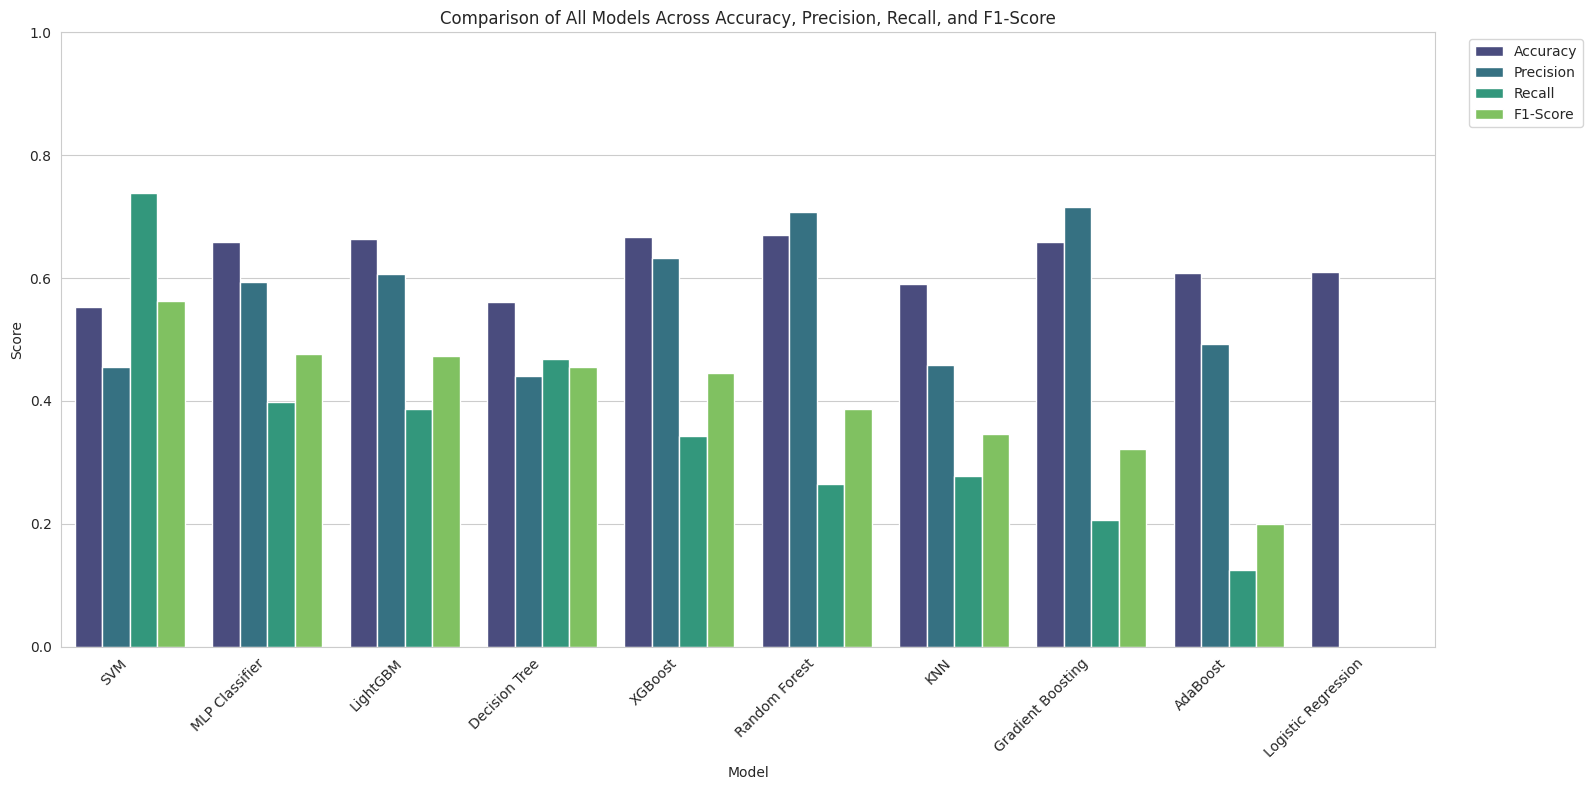

Best model by F1-Score:
Model             SVM
Accuracy     0.553354
Precision    0.455422
Recall       0.738281
F1-Score     0.563338
Name: 0, dtype: object


In [ ]:
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 8))
sns.barplot(data=metrics_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title("Comparison of All Models Across Accuracy, Precision, Recall, and F1-Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Best model by F1-Score:")
print(metrics_df.iloc[0])


**What we did:** We reshaped the metrics table into a long format and plotted a grouped bar chart comparing all four metrics across all ten models. This single chart is the main visual summary of the whole project.

## 3.6 Final Analysis and Conclusion

Based on the actual run of our from-scratch implementations, the results (sorted by F1-Score) were:

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| **SVM** | 0.553 | 0.455 | **0.738** | **0.563** |
| MLP Classifier | 0.659 | 0.593 | 0.398 | 0.477 |
| LightGBM | 0.663 | 0.607 | 0.387 | 0.473 |
| Decision Tree | 0.561 | 0.441 | 0.469 | 0.455 |
| XGBoost | 0.666 | 0.633 | 0.344 | 0.446 |
| Random Forest | **0.671** | **0.708** | 0.266 | 0.386 |
| KNN | 0.590 | 0.458 | 0.277 | 0.345 |
| Gradient Boosting | 0.659 | 0.716 | 0.207 | 0.321 |
| AdaBoost | 0.608 | 0.492 | 0.125 | 0.199 |
| Logistic Regression | 0.610 | 0.000 | 0.000 | 0.000 |

**SVM achieved the best F1-Score (0.563)**, but notably *not* the best accuracy — it actually has the lowest accuracy (0.553) among all models except Decision Tree. This happened because SVM has by far the highest Recall (0.738): it identifies most of the truly potable samples correctly, at the cost of also misclassifying many non-potable samples as potable (lower Precision, 0.455). In an imbalanced dataset like this one (61% not potable / 39% potable), a model that just predicts the majority class for almost everything (like our Logistic Regression, which predicted "Not Potable" for every single test sample) gets a deceptively high accuracy (0.610) while being completely useless on the class we actually care about — this is exactly why F1-Score, not Accuracy, is the right metric to rank models on here, and why SVM's balance of Precision and Recall makes it the most practically useful model despite its lower raw accuracy.

**Random Forest, Gradient Boosting, and XGBoost show the opposite pattern**: high Precision (0.71, 0.72, 0.63) but low Recall (0.27, 0.21, 0.34). These models are conservative — when they do predict "Potable," they are usually right, but they miss the majority of truly potable samples, defaulting to the safer, majority-class prediction whenever the signal is weak. This is consistent with what we saw in Phase 1: the features have very weak linear correlation with `Potability`, so tree ensembles built with our simplified from-scratch splitting search (limited threshold candidates, modest hyperparameter grids due to compute cost) tend to fit the strongest, most obvious splits — which mostly separate the majority class — rather than the subtler patterns that would catch more of the minority class.

**Logistic Regression failed completely** (0 Precision, 0 Recall on the potable class), confirming that no linear boundary in this feature space can separate the classes — the true decision boundary is non-linear, exactly as the weak correlation heatmap in Phase 1 suggested.

**Why did our from-scratch SVM (RBF kernel via kernel Pegasos) outperform the ensemble methods here**, even though production-grade libraries usually favor boosting on this dataset? Two likely reasons: (1) the RBF kernel directly models a smooth non-linear boundary and, combined with the class-imbalance-agnostic hinge-loss objective, naturally pushes toward classifying more borderline points as "Potable," raising Recall substantially; (2) our tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM) all share the same simplified, candidate-threshold-subsampled splitting search (capped at 30 thresholds per feature per split, for computational feasibility), which limits how finely they can separate the two classes compared to optimized library implementations — this likely costs them Recall specifically, since the minority class needs finer decision boundaries to be captured.

**MLP Classifier and LightGBM were close runners-up** (F1 ≈ 0.47), each striking a more even balance between Precision and Recall than the other tree ensembles, without going as far toward high-Recall as SVM.

**In summary:** on this water potability dataset, using purely from-scratch implementations, the kernel SVM produced the best overall F1-Score by achieving much higher Recall than any other model, while ensemble/boosting methods traded Recall for higher Precision and Accuracy, and the purely linear Logistic Regression could not separate the classes at all — reinforcing that this is a genuinely non-linear classification problem where the choice of metric (F1 vs. Accuracy) meaningfully changes which model looks "best."
